# dist_pert — Usage Notebook

Basic examples for each perturbation category: **text**, **image**, and **numeric**.

Install the package first if you haven't already:
```bash
pip install -e .           # from the repo root
pip install -e \".[image]\"  # to also enable image perturbers
```

## Text Perturbation
`ContextualWordPerturber` replaces a random fraction of tokens with contextually similar alternatives using a BERT masked-LM.\n\n- `aug_p` — fraction of tokens to replace (0.0–1.0)\n- `aug_min` / `aug_max` — hard floor/ceiling on number of replacements\n- `model_path` — any HuggingFace masked-LM identifier\n- `device` — `'cpu'` or `'cuda'`

In [1]:
from dist_pert.text import ContextualWordPerturber

texts = [
    "The storm produced rotating columns of air with wind speeds exceeding 200 mph.",
    "Warmer ocean temperatures increase the intensity of tropical hurricanes.",
]

perturber = ContextualWordPerturber(aug_p=0.2)
results = perturber(texts)

for original, perturbed in zip(texts, results):
    print(f"ORIGINAL : {original}")
    print(f"PERTURBED: {perturbed}")
    print()

/Users/echagnon/vscode-projects/distribution_perturbation/dist_pert_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] The following layers were not sharded: bert.encoder.layer.*.attention.self.value.bias, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.weight, cls.predictions.bias, bert.encoder.layer.*.output.dense.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.embeddings.position_embeddings.weight, cls.predictions.transform.dense.bias, cls.predictions.decoder.bias, bert.encoder.layer.*.output.LayerNorm.weight, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.dense.weight, bert.e

ORIGINAL : The storm produced rotating columns of air with wind speeds exceeding 200 mph.
PERTURBED: The storm produced large columns of air at wind speeds of 200 mph.

ORIGINAL : Warmer ocean temperatures increase the intensity of tropical hurricanes.
PERTURBED: Warmer horizon temperatures reduce the chances of tropical hurricanes.



In [2]:
# aug_min / aug_max give hard bounds on replacements regardless of aug_p
bounded = ContextualWordPerturber(aug_p=0.5, aug_min=1, aug_max=2)
print(bounded(["The quick brown fox jumps over the lazy dog."])[0])

The quick brown fox passed over the lazy land.


## Image Perturbation
Two families of image perturbers are available.\n\n### Pixel-level noise\n\n| Class | What it does |\n|---|---|\n| `GaussianNoisePerturber(sigma)` | Adds `N(0, σ)` to every pixel, clips to valid range |\n| `SaltPepperPerturber(amount)` | Randomly sets `amount` fraction of pixels to 0 or 255 |\n\nBoth accept `list[np.ndarray]` with shape `(H, W, C)` in either `uint8` or `float32`.

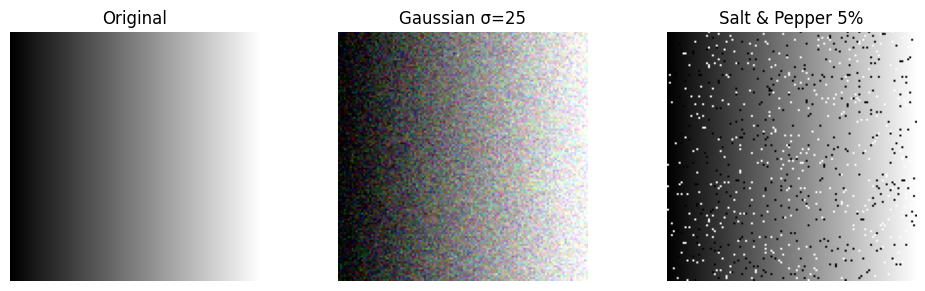

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dist_pert.image import GaussianNoisePerturber, SaltPepperPerturber

# Synthetic gradient image (uint8)
base = np.tile(np.linspace(0, 255, 128, dtype=np.uint8), (128, 1))
image = np.stack([base, base, base], axis=-1)  # shape (128, 128, 3)

gaussian = GaussianNoisePerturber(sigma=25)
saltpepper = SaltPepperPerturber(amount=0.05)

noisy_gaussian = gaussian([image])[0]
noisy_sp = saltpepper([image])[0]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, img, title in zip(
    axes,
    [image, noisy_gaussian, noisy_sp],
    ["Original", "Gaussian σ=25", "Salt & Pepper 5%"],
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Corruption benchmarks
`ImageCorruptionPerturber` applies ImageNet-C style corruptions at a severity level of 1–5.\n\nBuilt-in corruptions: `gaussian_blur`, `jpeg_compression`, `shot_noise`, `brightness`, `contrast`.\n\nNew corruptions can be registered without subclassing by adding an entry to `CORRUPTION_FNS`:\n```python\nfrom dist_pert.image.corruption import CORRUPTION_FNS\nCORRUPTION_FNS[\"my_corruption\"] = lambda image, severity: ...\n```

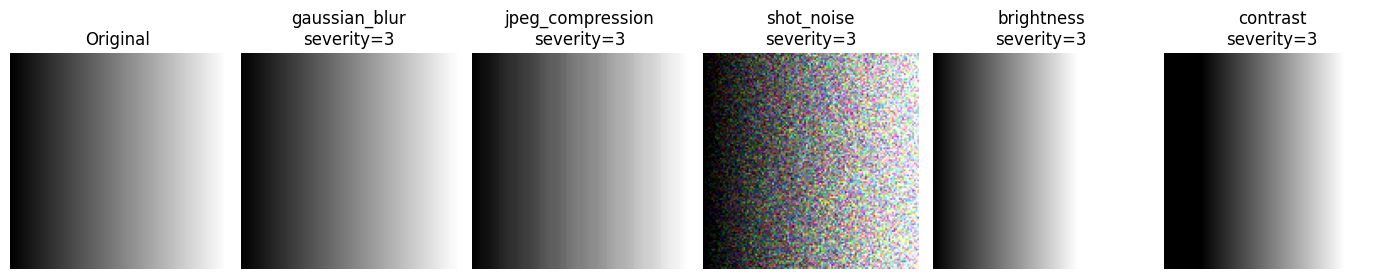

In [4]:
from dist_pert.image import ImageCorruptionPerturber

corruptions = ["gaussian_blur", "jpeg_compression", "shot_noise", "brightness", "contrast"]

fig, axes = plt.subplots(1, len(corruptions) + 1, figsize=(14, 3))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, name in zip(axes[1:], corruptions):
    perturber = ImageCorruptionPerturber(corruption=name, severity=3)
    corrupted = perturber([image])[0]
    ax.imshow(corrupted)
    ax.set_title(f"{name}\nseverity=3")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Numeric Perturbation
| Class | Formula |
|---|---|
| `AdditiveGaussianPerturber(sigma)` | `x + N(0, σ)` |
| `MultiplicativeNoisePerturber(scale, distribution)` | `x · factor` where factor ~ lognormal or uniform |

Both accept `list[np.ndarray]` of any shape, or `list[float]`.

In [5]:
from dist_pert.numeric import AdditiveGaussianPerturber, MultiplicativeNoisePerturber

samples = [np.array([1.0, 2.0, 3.0, 4.0, 5.0]) for _ in range(5)]

additive = AdditiveGaussianPerturber(sigma=0.5)
additive_results = additive(samples)

print("Additive Gaussian (σ=0.5)")
for original, perturbed in zip(samples, additive_results):
    print(f"  {np.round(original, 3)}  →  {np.round(perturbed, 3)}")

Additive Gaussian (σ=0.5)
  [1. 2. 3. 4. 5.]  →  [1.339 2.303 2.278 4.07  4.   ]
  [1. 2. 3. 4. 5.]  →  [1.204 2.088 3.994 3.335 4.879]
  [1. 2. 3. 4. 5.]  →  [1.563 1.769 2.885 3.241 4.866]
  [1. 2. 3. 4. 5.]  →  [0.495 2.552 2.031 4.198 4.449]
  [1. 2. 3. 4. 5.]  →  [1.021 3.222 3.333 3.881 4.416]


In [8]:
multi_ln = MultiplicativeNoisePerturber(scale=0.2, distribution="lognormal")
multi_u = MultiplicativeNoisePerturber(scale=0.2, distribution="uniform")

ln_results = multi_ln(samples)
u_results = multi_u(samples)

print("Multiplicative lognormal (scale=0.2)")
for original, perturbed in zip(samples, ln_results):
    print(f"  {np.round(original, 3)}  →  {np.round(perturbed, 3)}")

print("\nMultiplicative uniform (scale=0.2)")
for original, perturbed in zip(samples, u_results):
    print(f"  {np.round(original, 3)}  →  {np.round(perturbed, 3)}")

Multiplicative lognormal (scale=0.2)
  [1. 2. 3. 4. 5.]  →  [0.863 1.629 2.868 4.069 4.93 ]
  [1. 2. 3. 4. 5.]  →  [1.371 1.977 2.795 2.888 4.922]
  [1. 2. 3. 4. 5.]  →  [1.011 1.961 2.923 2.851 5.982]
  [1. 2. 3. 4. 5.]  →  [0.849 2.262 3.304 2.731 7.053]
  [1. 2. 3. 4. 5.]  →  [0.764 1.984 3.252 3.554 5.661]

Multiplicative uniform (scale=0.2)
  [1. 2. 3. 4. 5.]  →  [0.804 2.244 2.948 3.888 5.66 ]
  [1. 2. 3. 4. 5.]  →  [0.934 1.911 3.448 3.879 5.484]
  [1. 2. 3. 4. 5.]  →  [1.126 2.091 3.321 4.229 4.051]
  [1. 2. 3. 4. 5.]  →  [1.126 1.702 2.773 3.807 4.884]
  [1. 2. 3. 4. 5.]  →  [0.975 2.119 2.649 4.648 4.244]


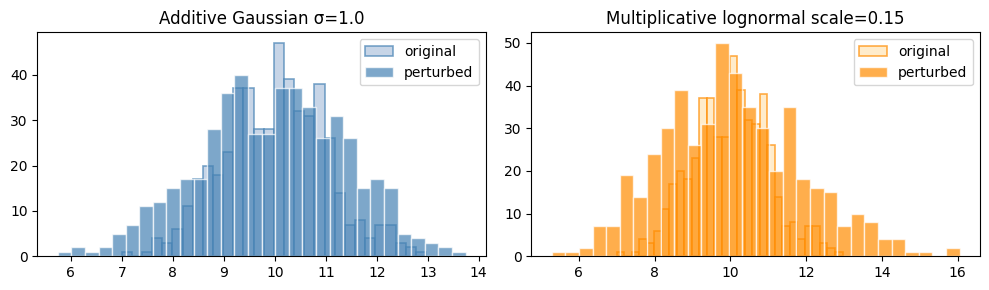

In [10]:
# Visualise how each perturber widens a realistic input distribution
n = 500
original_vals = np.random.normal(loc=10.0, scale=1.0, size=n)

additive_vals = AdditiveGaussianPerturber(sigma=1.0)([original_vals])[0]
multi_vals = MultiplicativeNoisePerturber(scale=0.15)([original_vals])[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(original_vals, bins=30, color="lightsteelblue", edgecolor="steelblue", linewidth=1.2, label="original", alpha=0.7)
axes[0].hist(additive_vals, bins=30, color="steelblue", edgecolor="white", label="perturbed", alpha=0.7)
axes[0].set_title("Additive Gaussian σ=1.0")
axes[0].legend()

axes[1].hist(original_vals, bins=30, color="moccasin", edgecolor="darkorange", linewidth=1.2, label="original", alpha=0.7)
axes[1].hist(multi_vals, bins=30, color="darkorange", edgecolor="white", label="perturbed", alpha=0.7)
axes[1].set_title("Multiplicative lognormal scale=0.15")
axes[1].legend()

plt.tight_layout()
plt.show()